# 08 — Classification: Match Outcome Prediction (Win / Draw / Loss)

**Input:** `match_features_train.parquet` (794 matches) · `match_features_test.parquet` (250 matches)  
**Target:** `outcome` ∈ {H, D, A}  
**Models:** Logistic Regression, Random Forest  
**CV strategy:** `TimeSeriesSplit(n_splits=3)` — respects temporal order, no future leakage  
**Primary metric:** Macro F1 (handles near-balanced 3-class problem)

In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

DS_DIR       = Path('../data/data_backup/processed')
OUT_DS_DIR   = Path('../data/processed/datasets')
MODEL_DIR    = Path('../data/models/classification')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

LABEL_ORDER = ['H', 'D', 'A']   # home win / draw / away win
SEED = 42

print('Libraries loaded.')

Libraries loaded.


## 1 — Load & Validate

In [2]:
train = pd.read_parquet(DS_DIR / 'match_features_train.parquet')
test  = pd.read_parquet(DS_DIR / 'match_features_test.parquet')

# Enforce temporal ordering
train = train.sort_values('match_date').reset_index(drop=True)
test  = test.sort_values('match_date').reset_index(drop=True)

print(f'Train : {train.shape}   date range: {train["match_date"].min().date()} → {train["match_date"].max().date()}')
print(f'Test  : {test.shape}   date range: {test["match_date"].min().date()} → {test["match_date"].max().date()}')
print()
print('Outcome distribution (train):')
print(train['outcome'].value_counts().to_string())
print()
print('Outcome distribution (test):')
print(test['outcome'].value_counts().to_string())

Train : (794, 37)   date range: 2021-08-21 → 2024-05-19
Test  : (250, 37)   date range: 2024-08-24 → 2025-05-25

Outcome distribution (train):
outcome
A    283
H    278
D    233

Outcome distribution (test):
outcome
H    84
A    84
D    82


## 2 — Preprocessing

In [3]:
# ── Null imputation ──────────────────────────────────────────────────────────
# Position-specific composites are null when a team has no recorded player
# in that position group for a given match. Fill with training-set means.
impute_cols = [
    'h_att_composite',  'h_att2_composite', 'h_mid_composite', 'h_def_composite',
    'a_att_composite',  'a_att2_composite', 'a_mid_composite', 'a_def_composite',
]

fill_means = train[impute_cols].mean()          # fit on train only
train[impute_cols] = train[impute_cols].fillna(fill_means)
test[impute_cols]  = test[impute_cols].fillna(fill_means)

print(f'Train nulls after imputation : {train.isnull().sum().sum()}')
print(f'Test  nulls after imputation : {test.isnull().sum().sum()}')

Train nulls after imputation : 0
Test  nulls after imputation : 0


In [4]:
# ── Differential features ────────────────────────────────────────────────────
# Home − Away deltas encode the relative quality gap between the two sides,
# which is often more predictive than absolute values for a symmetric outcome.
def add_diffs(df):
    df = df.copy()
    df['weighted_diff']    = df['h_weighted_composite']  - df['a_weighted_composite']
    df['att_diff']         = df['h_att_composite']       - df['a_att_composite']
    df['att2_diff']        = df['h_att2_composite']      - df['a_att2_composite']
    df['mid_diff']         = df['h_mid_composite']       - df['a_mid_composite']
    df['def_diff']         = df['h_def_composite']       - df['a_def_composite']
    df['top3_diff']        = df['h_top3_composite']      - df['a_top3_composite']
    df['std_diff']         = df['h_composite_std']       - df['a_composite_std']
    df['gk_diff']          = df['h_gk_composite']        - df['a_gk_composite']
    df['n_def_diff']       = df['h_n_defenders']         - df['a_n_defenders']
    df['n_mid_diff']       = df['h_n_midfielders']       - df['a_n_midfielders']
    df['n_win_diff']       = df['h_n_wingers']           - df['a_n_wingers']
    df['n_fwd_diff']       = df['h_n_forwards']          - df['a_n_forwards']
    df['attack_str_diff']  = df['h_roll5_attack_str']    - df['a_roll5_attack_str']
    df['defence_str_diff'] = df['h_roll5_defence_str']   - df['a_roll5_defence_str']
    return df

train = add_diffs(train)
test  = add_diffs(test)

# ── Feature sets ─────────────────────────────────────────────────────────────
META_COLS = ['match_id', 'match_date', 'home_team', 'away_team', 'season', 'outcome']

# raw: all 29 original numeric features (home + away separately)
feat_raw  = [c for c in train.columns if c not in META_COLS and
             not c.endswith('_diff') or c == 'composite_diff']

# diff: 15 differential features only (home − away)
feat_diff = [
    'composite_diff', 'weighted_diff', 'att_diff', 'att2_diff', 'mid_diff',
    'def_diff', 'top3_diff', 'std_diff', 'gk_diff',
    'n_def_diff', 'n_mid_diff', 'n_win_diff', 'n_fwd_diff',
    'attack_str_diff', 'defence_str_diff',
]

print(f'feat_raw  : {len(feat_raw)} features')
print(f'feat_diff : {len(feat_diff)} features')

feat_raw  : 31 features
feat_diff : 15 features


## 3 — Baseline

In [5]:
y_train     = train['outcome']
y_test      = test['outcome']

# pandas 3.0 reads string columns from parquet as ArrowExtensionArray,
# which doesn't support numpy-style fancy indexing used by sklearn's CV splitter.
# Force a plain numpy object array to avoid the TypeError.
y_train_arr = np.array(y_train, dtype=object)
y_test_arr  = np.array(y_test,  dtype=object)

dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy.fit(train[feat_raw], y_train_arr)
y_pred_dummy = dummy.predict(test[feat_raw])

baseline_acc = accuracy_score(y_test_arr, y_pred_dummy)
baseline_f1  = f1_score(y_test_arr, y_pred_dummy, average='macro', zero_division=0)
majority_cls = y_train.value_counts().idxmax()

print(f'Baseline — always predict "{majority_cls}" (most frequent in train):')
print(f'  Accuracy : {baseline_acc:.4f}')
print(f'  Macro F1 : {baseline_f1:.4f}')

Baseline — always predict "A" (most frequent in train):
  Accuracy : 0.3360
  Macro F1 : 0.1677


## 4 — Cross-Validation Setup

In [6]:
# TimeSeriesSplit with 3 folds — roughly one season per validation fold.
# Train must be sorted by match_date (done above) for this to be valid.
tscv = TimeSeriesSplit(n_splits=3)

X_dummy = train[feat_raw].values
print('Fold sizes:')
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_dummy), 1):
    tr_dates  = train['match_date'].iloc[[tr_idx[0],  tr_idx[-1]]].dt.date.tolist()
    val_dates = train['match_date'].iloc[[val_idx[0], val_idx[-1]]].dt.date.tolist()
    print(f'  Fold {fold}: train {len(tr_idx):3d} ({tr_dates[0]}→{tr_dates[1]})  '
          f'val {len(val_idx):3d} ({val_dates[0]}→{val_dates[1]})')

Fold sizes:
  Fold 1: train 200 (2021-08-21→2022-03-17)  val 198 (2022-03-19→2023-01-21)
  Fold 2: train 398 (2021-08-21→2023-01-21)  val 198 (2023-01-21→2023-10-23)
  Fold 3: train 596 (2021-08-21→2023-10-23)  val 198 (2023-10-27→2024-05-19)


## 5 — Logistic Regression

In [7]:
lr_param_grid = {
    'C':      [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga'],
}

results_lr = []

for feat_name, feats in [('raw', feat_raw), ('diff', feat_diff)]:
    X = train[feats].values
    lr = LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=SEED,
    )
    gs = GridSearchCV(
        lr, lr_param_grid,
        cv=tscv,
        scoring='f1_macro',
        n_jobs=1,
        refit=True,
    )
    gs.fit(X, y_train_arr)
    results_lr.append({
        'model':       'LogReg',
        'features':    feat_name,
        'feat_list':   feats,
        'best_params': gs.best_params_,
        'cv_f1_macro': gs.best_score_,
        'estimator':   gs.best_estimator_,
    })
    print(f'LogReg [{feat_name:4s}]  CV Macro F1: {gs.best_score_:.4f}  '
          f'best params: {gs.best_params_}')

LogReg [raw ]  CV Macro F1: 0.5120  best params: {'C': 100, 'solver': 'lbfgs'}
LogReg [diff]  CV Macro F1: 0.4980  best params: {'C': 10, 'solver': 'lbfgs'}


## 6 — Random Forest

In [8]:
rf_param_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [5, 8, None],
    'min_samples_leaf': [5, 10, 20],
    'max_features':     ['sqrt', 0.5],
}

results_rf = []

for feat_name, feats in [('raw', feat_raw), ('diff', feat_diff)]:
    X = train[feats].values
    rf = RandomForestClassifier(
        class_weight='balanced',
        random_state=SEED,
        n_jobs=1,
    )
    gs = GridSearchCV(
        rf, rf_param_grid,
        cv=tscv,
        scoring='f1_macro',
        n_jobs=1,
        refit=True,
    )
    gs.fit(X, y_train_arr)
    results_rf.append({
        'model':       'RandomForest',
        'features':    feat_name,
        'feat_list':   feats,
        'best_params': gs.best_params_,
        'cv_f1_macro': gs.best_score_,
        'estimator':   gs.best_estimator_,
    })
    print(f'RF [{feat_name:4s}]      CV Macro F1: {gs.best_score_:.4f}  '
          f'best params: {gs.best_params_}')

RF [raw ]      CV Macro F1: 0.5418  best params: {'max_depth': 8, 'max_features': 0.5, 'min_samples_leaf': 20, 'n_estimators': 100}
RF [diff]      CV Macro F1: 0.5167  best params: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 100}


## 7 — CV Results Summary

In [9]:
all_results = results_lr + results_rf
all_results.sort(key=lambda r: r['cv_f1_macro'], reverse=True)

summary_cv = pd.DataFrame([{
    'Model':          r['model'],
    'Features':       r['features'],
    'CV Macro F1':    round(r['cv_f1_macro'], 4),
    'Best Params':    str(r['best_params']),
} for r in all_results])

print('CV results (sorted by Macro F1):')
print(summary_cv.to_string(index=False))
print()

best_result = all_results[0]
print(f'Best: {best_result["model"]} [{best_result["features"]}]  '
      f'CV F1={best_result["cv_f1_macro"]:.4f}')

CV results (sorted by Macro F1):
       Model Features  CV Macro F1                                                                           Best Params
RandomForest      raw       0.5418    {'max_depth': 8, 'max_features': 0.5, 'min_samples_leaf': 20, 'n_estimators': 100}
RandomForest     diff       0.5167 {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 100}
      LogReg      raw       0.5120                                                         {'C': 100, 'solver': 'lbfgs'}
      LogReg     diff       0.4980                                                          {'C': 10, 'solver': 'lbfgs'}

Best: RandomForest [raw]  CV F1=0.5418


## 8 — Test Set Evaluation

In [10]:
# ── Best model on test ───────────────────────────────────────────────────────
best_est   = best_result['estimator']
best_feats = best_result['feat_list']

X_test_best = test[best_feats].values
y_pred_best = best_est.predict(X_test_best)

acc    = accuracy_score(y_test_arr, y_pred_best)
f1_mac = f1_score(y_test_arr, y_pred_best, average='macro')

print(f'Test results — {best_result["model"]} [{best_result["features"]}]')
print(f'  Accuracy  : {acc:.4f}   (baseline: {baseline_acc:.4f},  Δ={acc-baseline_acc:+.4f})')
print(f'  Macro F1  : {f1_mac:.4f}   (baseline: {baseline_f1:.4f},  Δ={f1_mac-baseline_f1:+.4f})')
print()
print(classification_report(y_test_arr, y_pred_best, target_names=LABEL_ORDER, digits=3))

Test results — RandomForest [raw]
  Accuracy  : 0.5480   (baseline: 0.3360,  Δ=+0.2120)
  Macro F1  : 0.5353   (baseline: 0.1677,  Δ=+0.3676)

              precision    recall  f1-score   support

           H      0.551     0.643     0.593        84
           D      0.500     0.329     0.397        82
           A      0.571     0.667     0.615        84

    accuracy                          0.548       250
   macro avg      0.541     0.546     0.535       250
weighted avg      0.541     0.548     0.536       250



In [11]:
# ── All models on test (comparison table) ────────────────────────────────────
rows = [{
    'Model':    'Baseline (majority)',
    'Features': '—',
    'Accuracy': round(baseline_acc, 4),
    'Macro F1': round(baseline_f1,  4),
}]

for r in all_results:
    X_t = test[r['feat_list']].values
    yp  = r['estimator'].predict(X_t)
    rows.append({
        'Model':    r['model'],
        'Features': r['features'],
        'Accuracy': round(accuracy_score(y_test_arr, yp), 4),
        'Macro F1': round(f1_score(y_test_arr, yp, average='macro'), 4),
    })

comp = (pd.DataFrame(rows)
          .sort_values('Macro F1', ascending=False)
          .reset_index(drop=True))

print('All models — test set:')
print(comp.to_string(index=False))

All models — test set:
              Model Features  Accuracy  Macro F1
             LogReg      raw     0.556    0.5494
       RandomForest     diff     0.552    0.5401
       RandomForest      raw     0.548    0.5353
             LogReg     diff     0.540    0.5268
Baseline (majority)        —     0.336    0.1677


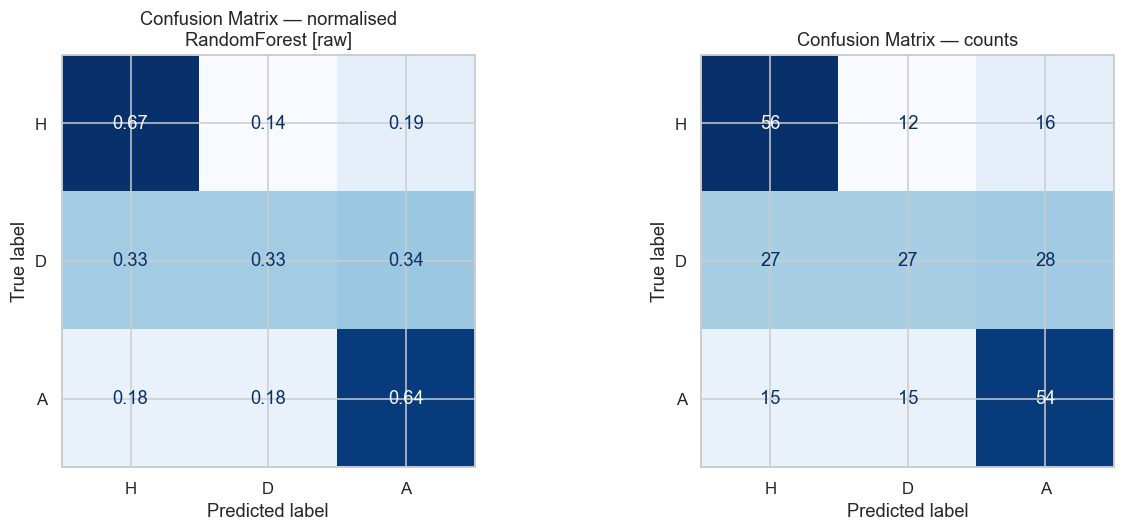

In [12]:
# ── Confusion matrix ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_norm = confusion_matrix(y_test_arr, y_pred_best, labels=LABEL_ORDER, normalize='true')
ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=LABEL_ORDER).plot(
    ax=axes[0], cmap='Blues', colorbar=False, values_format='.2f'
)
axes[0].set_title(f'Confusion Matrix — normalised\n{best_result["model"]} [{best_result["features"]}]',
                  fontsize=12)

cm_raw = confusion_matrix(y_test_arr, y_pred_best, labels=LABEL_ORDER)
ConfusionMatrixDisplay(confusion_matrix=cm_raw, display_labels=LABEL_ORDER).plot(
    ax=axes[1], cmap='Blues', colorbar=False, values_format='d'
)
axes[1].set_title('Confusion Matrix — counts', fontsize=12)

plt.tight_layout()
plt.show()

## 9 — Feature Importance

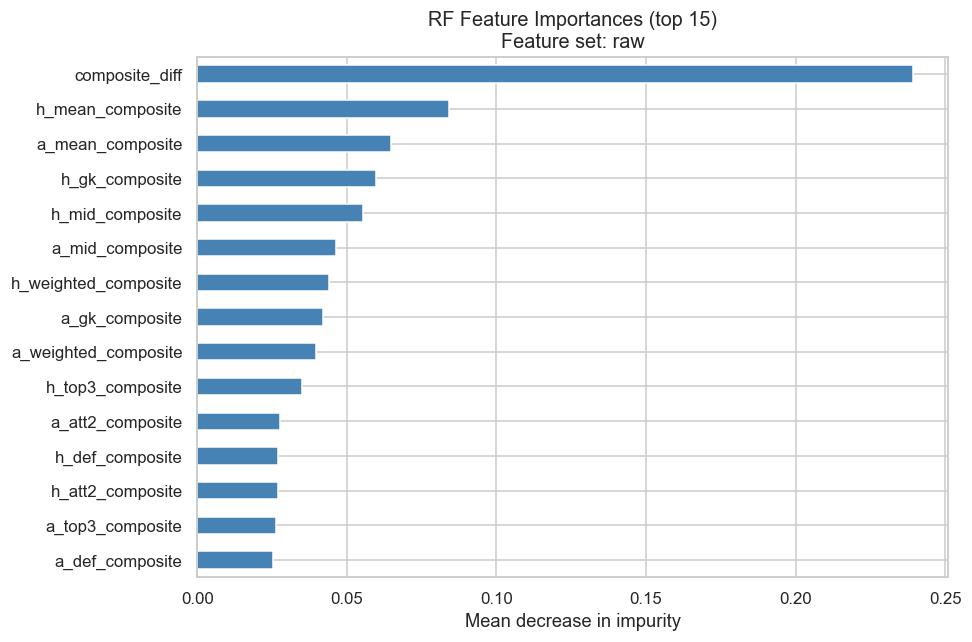

In [13]:
if best_result['model'] == 'RandomForest':
    fi = (pd.Series(best_est.feature_importances_, index=best_feats)
            .sort_values(ascending=True)
            .tail(15))

    fig, ax = plt.subplots(figsize=(9, 6))
    fi.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'RF Feature Importances (top 15)\nFeature set: {best_result["features"]}',
                 fontsize=13)
    ax.set_xlabel('Mean decrease in impurity')
    plt.tight_layout()
    plt.show()

elif best_result['model'] == 'LogReg':
    coef_df = pd.DataFrame(
        best_est.coef_,
        index=best_est.classes_,
        columns=best_feats,
    ).T.sort_values('H', ascending=False)

    fig, ax = plt.subplots(figsize=(11, max(7, len(best_feats) * 0.35)))
    sns.heatmap(coef_df, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
                ax=ax, linewidths=0.4, cbar_kws={'shrink': 0.6})
    ax.set_title(f'LogReg Coefficients per Class\nFeature set: {best_result["features"]}',
                 fontsize=13)
    plt.tight_layout()
    plt.show()

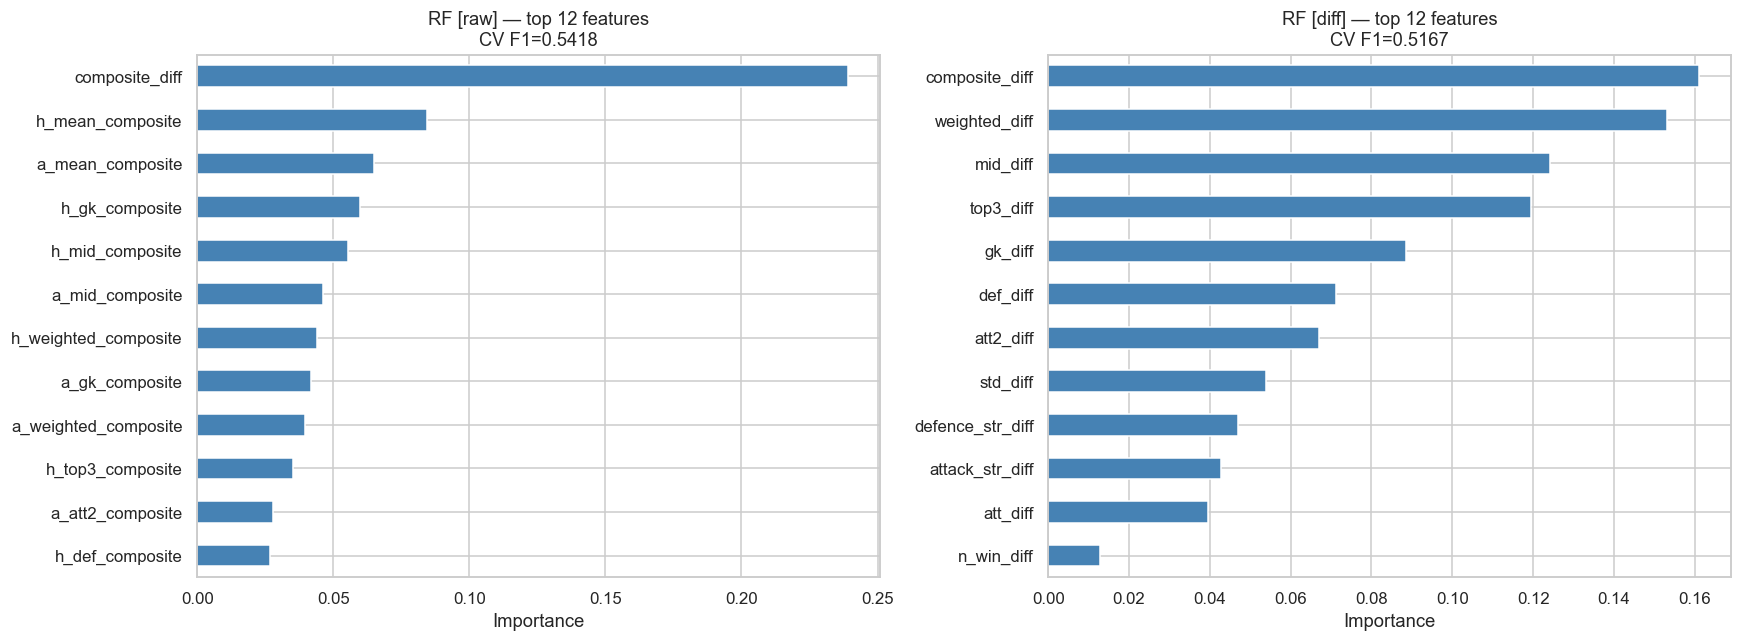

In [14]:
# ── Feature importance for all models side-by-side (RF only) ─────────────────
rf_results = [r for r in all_results if r['model'] == 'RandomForest']

if len(rf_results) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, r in zip(axes, rf_results):
        fi = (pd.Series(r['estimator'].feature_importances_, index=r['feat_list'])
                .sort_values(ascending=True)
                .tail(12))
        fi.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
        ax.set_title(f'RF [{r["features"]}] — top 12 features\nCV F1={r["cv_f1_macro"]:.4f}',
                     fontsize=12)
        ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

## 10 — Save Artefacts

In [15]:
# ── Save best model ───────────────────────────────────────────────────────────
model_fname = f'classifier_{best_result["model"].lower()}_{best_result["features"]}.pkl'
model_path  = MODEL_DIR / model_fname
with open(model_path, 'wb') as f:
    pickle.dump(best_est, f)
print(f'Saved model : {model_path}')

# ── Save all trained estimators ───────────────────────────────────────────────
for r in all_results:
    fname = f'classifier_{r["model"].lower()}_{r["features"]}.pkl'
    with open(MODEL_DIR / fname, 'wb') as f:
        pickle.dump(r['estimator'], f)
print(f'Saved all {len(all_results)} estimators to {MODEL_DIR}')

# ── Save imputation fill means ────────────────────────────────────────────────
with open(MODEL_DIR / 'impute_means_match.pkl', 'wb') as f:
    pickle.dump(fill_means, f)
print('Saved imputation means.')

# ── Save test predictions ─────────────────────────────────────────────────────
pred_df = test[['match_id', 'match_date', 'home_team', 'away_team',
                'season', 'outcome']].copy()
pred_df['predicted'] = y_pred_best
pred_df['correct']   = (pred_df['predicted'] == pred_df['outcome']).astype(int)

if hasattr(best_est, 'predict_proba'):
    proba = best_est.predict_proba(X_test_best)
    for i, cls in enumerate(best_est.classes_):
        pred_df[f'prob_{cls}'] = proba[:, i]

pred_path = OUT_DS_DIR / 'match_predictions_test.parquet'
pred_df.to_parquet(pred_path, index=False)
print(f'Saved predictions: {pred_path}')

print()
print('── Final summary ──────────────────────────────────────')
print(f'Best model    : {best_result["model"]} [{best_result["features"]}]')
print(f'Best params   : {best_result["best_params"]}')
print(f'CV Macro F1   : {best_result["cv_f1_macro"]:.4f}')
print(f'Test Accuracy : {acc:.4f}')
print(f'Test Macro F1 : {f1_mac:.4f}')
print(f'Baseline F1   : {baseline_f1:.4f}')

Saved model : ..\data\models\classification\classifier_randomforest_raw.pkl
Saved all 4 estimators to ..\data\models\classification
Saved imputation means.
Saved predictions: ..\data\processed\datasets\match_predictions_test.parquet

── Final summary ──────────────────────────────────────
Best model    : RandomForest [raw]
Best params   : {'max_depth': 8, 'max_features': 0.5, 'min_samples_leaf': 20, 'n_estimators': 100}
CV Macro F1   : 0.5418
Test Accuracy : 0.5480
Test Macro F1 : 0.5353
Baseline F1   : 0.1677
